# Trabajo Práctico #2 | Un Primer Encuentro con la EPH
#### Grupo # 2 conformado por Juan Bonilla & Aroon Vargas V.

Link repositorio: https://github.com/juanditelli99/BD-ML_UBA26

## Parte 1: Familiarización con la EPH y limpieza

In [5]:
# Librerías a utilizar
# Fijate si en tu terminal tienes bajada todas las libs a utilizar. Seaborn no la tenías por ejemplo

import pandas as pd
import openpyxl as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Metemos los dfs

df_25 = pd.read_excel("EPH_usu_individual_T125.xlsx")
df_24 = pd.read_excel("EPH_usu_individual_T124.xlsx")

#### 2a. Tenemos que seleccionar nuestras variables de interés dentro de la EPH. La consigna nos pide 13 variables obligatorias + 5 variables identificadoras + 7 variables de libre elección (me interesó, a grandes rasgos, la informalidad y los beneficios laborales)

In [ ]:
# Variables de identificación. En orden, estas son: Code para distinguir VIVIENDAS, Año de Relevamiento, 
# Nro. de Trimestre, Code para distinguir HOGARES, Ponderación 

id_vars = ['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'PONDERA']

# Variables obligatorias + de libre elección

vars_choice = [
    'CH04', 'CH06', 'CH07', 'CH08',     # sexo, edad, estado civil, tipo de cobertura médica
    'NIVEL_ED',                         # nivel educativo
    'ESTADO',                           # condición de actividad  
    'CAT_OCUP',                         # categoría ocupacional 
    'EMPLEO',                           # tipo de empleo  
    'SECTOR',                           # sector formal/informal/hogares 
    'PP04C',                            # tamaño del establecimiento  
    'PP04D_COD',                        # código de ocupación (por Clasificador Nacional de Ocupaciones, v 2001) 
    'P21',                              # ingreso ocupación principal
    'P47T',                             # ingreso total individual (ingresos laborales + no laborales) -hacia abajo arrancan las escogidas-
    'PP07H',                            # descuento jubilatorio (proxy informalidad) 
    'PP07I',                            # aporte voluntario ANSES (relacionada con la var anterior; sino es trabajo formal queremos saber si aporta o no al sist. jubilatorio) (check)
    'PP07J',                            # tipo de turno habitual de trabajo 
    'PP07K',                            # cómo cobra el salario
    'PP07L',                            # cobra la totalidad del suelo en el recibo (recibo como referencia a la var anterior) 
    'PP07M',                            # parte aprox. que no contempla en su recibo de sueldo (menos o mitad/mas de su sueldo) 
    'CAT_INAC',                         # categoría de inactividad (jubilado, rentista, estudiante, ama de casa, etc.)  
]

total_vars = id_vars + vars_choice 

# Filtramos columnas en cada dataframe

df_24 = df_24[[c for c in total_vars if c in df_24.columns]].copy()  # Toma c para los c (elementos-columnas) dentro del listado de total_vars dentro de cada df
df_25 = df_25[[c for c in total_vars if c in df_25.columns]].copy()  # Idem para el otro df   
 
print("# filas y # columnas después de la selección de variables:")
print(f"  df_24: {df_24.shape}")
print(f"  df_25: {df_25.shape}")

# filas y # columnas después de la selección de variables:
  df_24: (46050, 25)
  df_25: (45425, 25)


Golazo: tenemos la misma cantidad de columnas en ambos dataframes. La pérdida de filas no considero que sea tan relevante.

#### 2b. Nos advierten de valores sin sentido (respuestas de ingreso 'negativas') en las variables. También, me gustaría garantizar tener strings o ints donde corresponda.

In [5]:
# Chequeamos para el primer df
# CH_NRO viene de características de la persona. De las ids vars, solo CODUSU debería ser string. 
df_24.dtypes

CODUSU           str
ANO4           int64
TRIMESTRE      int64
NRO_HOGAR      int64
PONDERA        int64
CH04           int64
CH06           int64
CH07           int64
CH08           int64
NIVEL_ED       int64
ESTADO         int64
CAT_OCUP       int64
EMPLEO       float64
SECTOR       float64
PP04C        float64
PP04D_COD    float64
P21            int64
P47T         float64
PP07H        float64
PP07I        float64
PP07J        float64
PP07K        float64
PP07L        float64
PP07M        float64
CAT_INAC       int64
dtype: object

A ojo podríamos revisar que cada variable sea del tipo correcto pero, nos demoramos mucho

In [6]:
# Variables que deben ser numéricas enteras
vars_int = ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO',
            'CAT_OCUP', 'EMPLEO', 'SECTOR', 'PP04C']
 
# Variables de ingreso ENTONCES numéricas float
vars_float = ['P21', 'P47T']
 
for var in vars_int:
    for df in [df_24, df_25]:
        if var in df.columns:
            df[var] = pd.to_numeric(df[var], errors='coerce')
 
for var in vars_float:
    for df in [df_24, df_25]:
        if var in df.columns:
            df[var] = pd.to_numeric(df[var], errors='coerce')
 
print("\nTipos de datos tras armonización (df_24):")
print(df_24[vars_int + vars_float].dtypes)


Tipos de datos tras armonización (df_24):
CH04          int64
CH06          int64
CH07          int64
CH08          int64
NIVEL_ED      int64
ESTADO        int64
CAT_OCUP      int64
EMPLEO      float64
SECTOR      float64
PP04C       float64
P21           int64
P47T        float64
dtype: object


In [7]:
df_24["EMPLEO"].isna().sum()

np.int64(25725)

Qué es lo que hice arriba? Variables como EMPLEO, cuando revisas el diccionario, deberían ser enteros -es una var categórica básicamente. Pero te dan float64 como si fueran decimales. Entonces corregí con el code penúlitmo de arriba, sin embargo, me volvió a dar EMPLEO con float64. 

Lo que está sucediendo es que al decirle a pandas que me lo haga numérico detecta probablemente que hay un missing value y, con el errors=coerce le digo que TODO nro. no válido me lo haga NaN. El NaN solo es soportado por el tipo de dato float64. Con el último code, lo que hacemos es sumar todos los na que se encuentran en EMPLEO y nos devuelve un entero de 25725 observaciones que contienen NaN. Así confirmamos lo anterior para EMPLEO y para otras variables.

Para posibles valores negativos, un sinsentido cuando nos referimos a ingresos por ejemplo, realizamos la siguiente limpieza. Antes, esto encontré en Anexo I del Diccionario: 

"Los códigos 9, 99, 999, 9999 corresponden, salvo indicación contraria, a la categoría No sabe/No responde. Una excepción la constituyen los montos de ingreso, en cuyo caso la no respuesta se identifica con el código -9."

Hay que limpiar esto que de seguro tenemos.

In [8]:
# Ingresos negativos o ceros ENTONCES NaN
# (la EPH codifica no respuesta de ingresos con -9 o valores negativos)
for var in vars_float:
    for df in [df_24, df_25]:
        if var in df.columns:
            df.loc[df[var] < 0, var] = np.nan
 
# Variables categóricas: deberían ser positivos SINO NaN (9 podría ser "no sabe" o "no responde")
for var in vars_int:
    for df in [df_24, df_25]:
        if var in df.columns:
            df.loc[df[var] < 0, var] = np.nan
 
print("\nValores faltantes tras limpieza (df_24):")
print(df_24[vars_choice].isna().sum())


Valores faltantes tras limpieza (df_24):
CH04             0
CH06           334
CH07             0
CH08             0
NIVEL_ED         0
ESTADO           0
CAT_OCUP         0
EMPLEO       25725
SECTOR       25725
PP04C        25725
PP04D_COD    25725
P21           3403
P47T          4943
PP07H        25725
PP07I        25725
PP07J        25725
PP07K        25725
PP07L        25725
PP07M        25725
CAT_INAC         0
dtype: int64


**Heatmap de Valores Faltantes**

2c. La idea es mostrar el % total de valores NaN por variable y para cada año, con la totalidad (N) observaciones de cada año.

Por si no se entiende esto dice $$miss_{24} = df_{24}[vars_choice].isna().mean() * 100$$ "los missing values del df_24 serán las variables dentro de vars_choice, haz un true or false para cada fila si hay NaN y después hazme el promedio". Ejemplo, si para P21 tengo solo 4 obs. que son dos true y dos false (es decir, 2 en total NaN) la media me dará que un 50% de las observaciones tienen missing values...


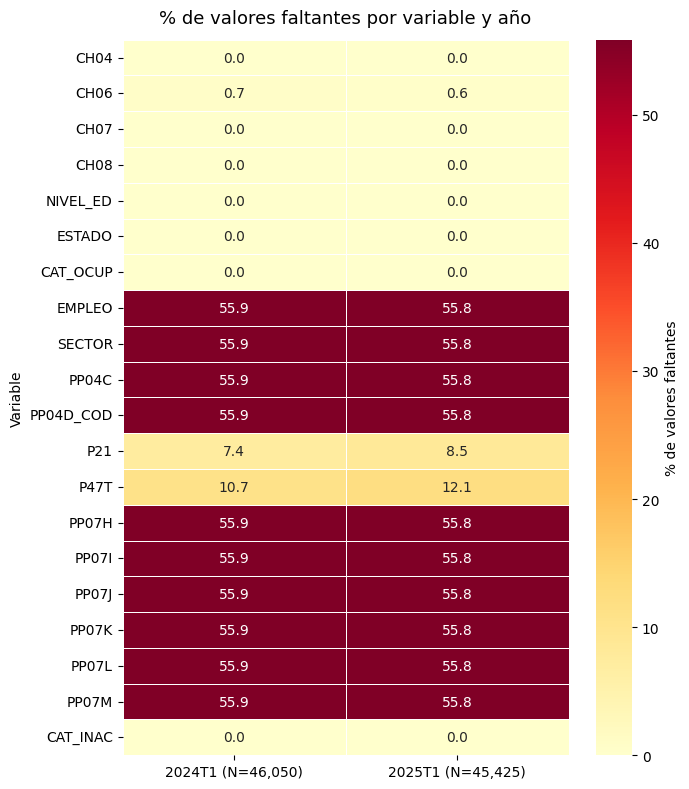

In [9]:
# Calculamos % de faltantes para cada año
miss_24 = df_24[vars_choice].isna().mean() * 100
miss_25 = df_25[vars_choice].isna().mean() * 100
 
miss_df = pd.DataFrame({
    f'2024T1 (N={len(df_24):,})': miss_24,
    f'2025T1 (N={len(df_25):,})': miss_25
})
 
fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(
    miss_df,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% de valores faltantes'}
)
ax.set_title("% de valores faltantes por variable y año", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.savefig("heatmap_faltantes.png", dpi=150)
plt.show()

Ahora siguiendo los **Principios de Schwabish (2014)**

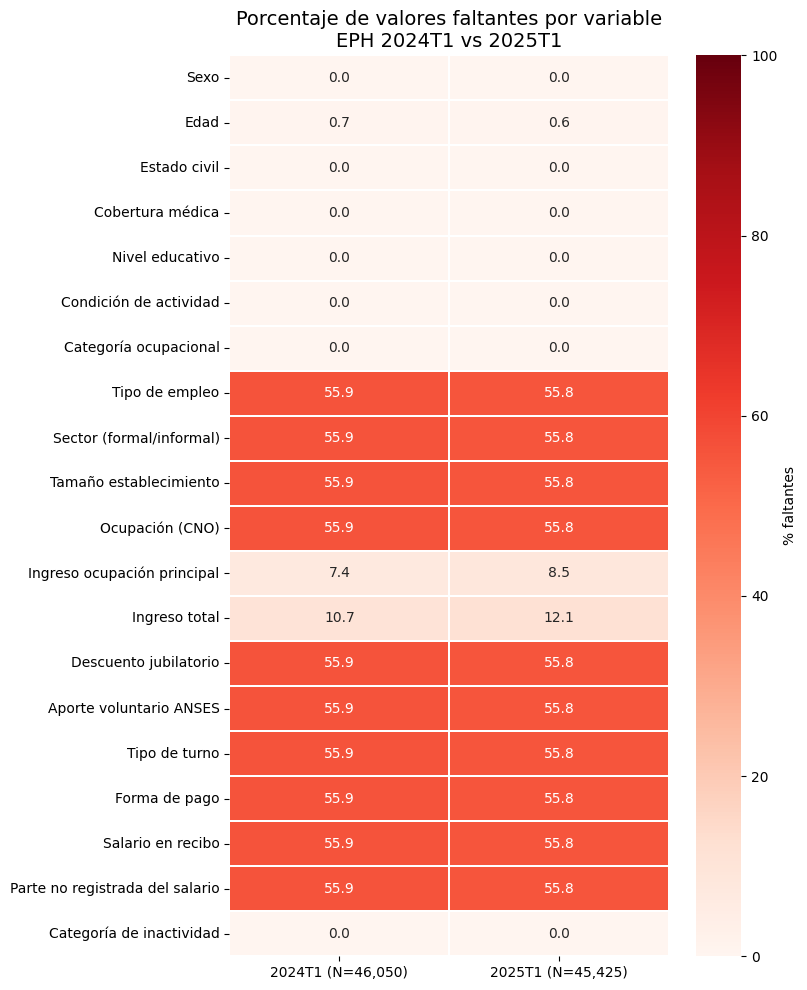

In [10]:
labels = {
    'CH04': 'Sexo',
    'CH06': 'Edad',
    'CH07': 'Estado civil',
    'CH08': 'Cobertura médica',
    'NIVEL_ED': 'Nivel educativo',
    'ESTADO': 'Condición de actividad',
    'CAT_OCUP': 'Categoría ocupacional',
    'EMPLEO': 'Tipo de empleo',
    'SECTOR': 'Sector (formal/informal)',
    'PP04C': 'Tamaño establecimiento',
    'PP04D_COD': 'Ocupación (CNO)',
    'P21': 'Ingreso ocupación principal',
    'P47T': 'Ingreso total',
    'PP07H': 'Descuento jubilatorio',
    'PP07I': 'Aporte voluntario ANSES',
    'PP07J': 'Tipo de turno',
    'PP07K': 'Forma de pago',
    'PP07L': 'Salario en recibo',
    'PP07M': 'Parte no registrada del salario',
    'CAT_INAC': 'Categoría de inactividad'
}

miss_24 = df_24[vars_choice].isna().mean() * 100
miss_25 = df_25[vars_choice].isna().mean() * 100

miss_df = pd.DataFrame({
    f'2024T1 (N={len(df_24):,})': miss_24,
    f'2025T1 (N={len(df_25):,})': miss_25
})

miss_df.index = [labels[v] for v in miss_df.index]

plt.figure(figsize=(8, 10))

ax = sns.heatmap(
    miss_df,
    annot=True,
    fmt=".1f",
    cmap="Reds",                 # más sobrio que YlOrRd
    vmin=0, vmax=100,            # escala consistente
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': '% faltantes'}
)

# Título claro y directo
ax.set_title("Porcentaje de valores faltantes por variable\nEPH 2024T1 vs 2025T1",
             fontsize=14)

# Sacamos ruido innecesario
ax.set_xlabel("")
ax.set_ylabel("")

# Mejorar legibilidad
plt.yticks(rotation=0, fontsize=10)
plt.xticks(fontsize=10)

# Quitar bordes innecesarios
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("heatmap_faltantes_pro.png", dpi=200)
plt.show()

2d. Creación de Variables Binarias  (pregunta pendiente)

Las variables categóricas por ahí tienen info que nosotros podríamos no necesitar de manera tan exahustiva. Nos puede interesar la informalidad y utilizar esa etiqueta para algunos valores categóricos de la variable SECTOR por ejemplo.

In [11]:
for df in [df_24, df_25]:
    # Sexo: CH04 == 1 --D varón
    df['d_varon']       = (df['CH04'] == 1).astype(int)
    # Sector formal: SECTOR == 1 --D formal. 0 sería Informal + Hogares + Ns/Nr.
    df['d_formal']    = (df['SECTOR'] == 1).astype(int)
    # Asalariado: CAT_OCUP == 3
    df['d_asalariado']  = (df['CAT_OCUP'] == 3).astype(int)
    # Cuentapropista: CAT_OCUP == 2
    df['d_cuentapropia']= (df['CAT_OCUP'] == 2).astype(int)
    # Universitario completo: NIVEL_ED == 6
    df['d_universitario']= (df['NIVEL_ED'] == 6).astype(int)
 
print("Binarias creadas - Ejemplo df_24:")
print(df_24[['d_varon','d_formal','d_asalariado','d_cuentapropia','d_universitario']].head())

Binarias creadas - Ejemplo df_24:
   d_varon  d_formal  d_asalariado  d_cuentapropia  d_universitario
0        0         0             0               0                0
1        1         0             0               1                0
2        1         0             0               1                0
3        0         0             0               0                1
4        0         0             0               1                0


2e. Actualización de las variables P21 y P47T

La forma que actualizamos es simplemente la siguiente: $$ X_{25} = X_{24} * 1.559 $$ 

La **variación interanual del nivel general del IPC a nivel nacional** fue del 55,9%. Ese dato fue extraído del informe de INDEC para Abril/25 que puede ser consultado en el siguiente link: https://www.indec.gob.ar/uploads/informesdeprensa/ipc_04_251F7DF5B2A3.pdf


In [12]:
factor_ipc = 1.559   # incorrecto valor de IPC? Reemplazar acá por el que más te guste... esto es ipc_mar_25 = 155.9 / ipc_mar_24 = 100
 
df_24['P21_real']  = df_24['P21']  * factor_ipc
df_24['P47T_real'] = df_24['P47T'] * factor_ipc
 
# En 2025 ya a precios corrientes del 1er trimestre (marzo 2025)
df_25['P21_real']  = df_25['P21']
df_25['P47T_real'] = df_25['P47T']
 
print(f"\nIngresos 2024 ajustados por IPC = {factor_ipc}")
print(f"Ingreso medio P21 2024 (nominal):  {df_24['P21'].mean():,.0f}")
print(f"Ingreso medio P21 2024 (real):     {df_24['P21_real'].mean():,.0f}")
print(f"Ingreso medio P21 2025:            {df_25['P21_real'].mean():,.0f}")


Ingresos 2024 ajustados por IPC = 1.559
Ingreso medio P21 2024 (nominal):  118,277
Ingreso medio P21 2024 (real):     184,394
Ingreso medio P21 2025:            278,026


**3. Cuántas personas no respondieron cuál es su condición de actividad (ESTADO)?** 

Entiendo que tendríamos que contar las observaciones con ESTADO = 0 EN AMBOS dfs -suponiendo que 'no hay' datos de panel o que, por lo menos para cada año, todas las observaciones son distintas.

In [40]:
# Mergeamos ambos años para analizar en conjunto la variable ESTADO (condición de actividad)
df_total = pd.concat([df_24, df_25], ignore_index=True)  # ignore_index=True es para que no una los index de primero un df y luego se apile debajo el otro. Estás volviendo a contar cada una de las observaciones desde 0.
 
# Cuántos no respondieron ESTADO? del Diccionario: "Condición de actividad 0 = Entrevista individual no realizada (no respuesta al cuestionario individual)"
no_resp_n = (df_total['ESTADO'] == 0).sum()
print(f"\nPersonas que no respondieron ESTADO (= 0): {no_resp_n:,}")
 
# Separamos en dos bases
df_resp   = df_total[df_total['ESTADO'] != 0].copy()
df_no_resp = df_total[df_total['ESTADO'] == 0].copy()
 
print(f"Base 'respondieron':    {len(df_resp):,} observaciones")
print(f"Base 'no_respondieron': {len(df_no_resp):,} observaciones")
 


Personas que no respondieron ESTADO (= 0): 156
Base 'respondieron':    91,319 observaciones
Base 'no_respondieron': 156 observaciones


**4. Dentro de df_resp hay que quedarse con quienes son ocupados (ESTADO == 1)** para así realizar el análisis de formalidad

In [23]:
# Submuestra de ocupados (ESTADO=1) dentro de los que respondieron

ocupados = df_resp[df_resp['ESTADO'] == 1].copy()
print(f"\nBase 'ocupados' (ESTADO=1): {len(ocupados):,} observaciones")


Base 'ocupados' (ESTADO=1): 40,401 observaciones


## Parte 2: Primer análisis exploratorio  

**5. Matriz de correlación entre 2024T1 y 2025T1 con las siguientes variables: SECTOR, ESTADO, CAT_OCU, P21, P47T, NIVEL ED, CH04, CH06, CH07, CH08**

Comentar los resultados en el Overleaf. Interesante correlación positiva por ej. entre nivel educativo e ingresos, mientras que variables asociadas a informalidad presentan correlaciones negativas con los ingresos

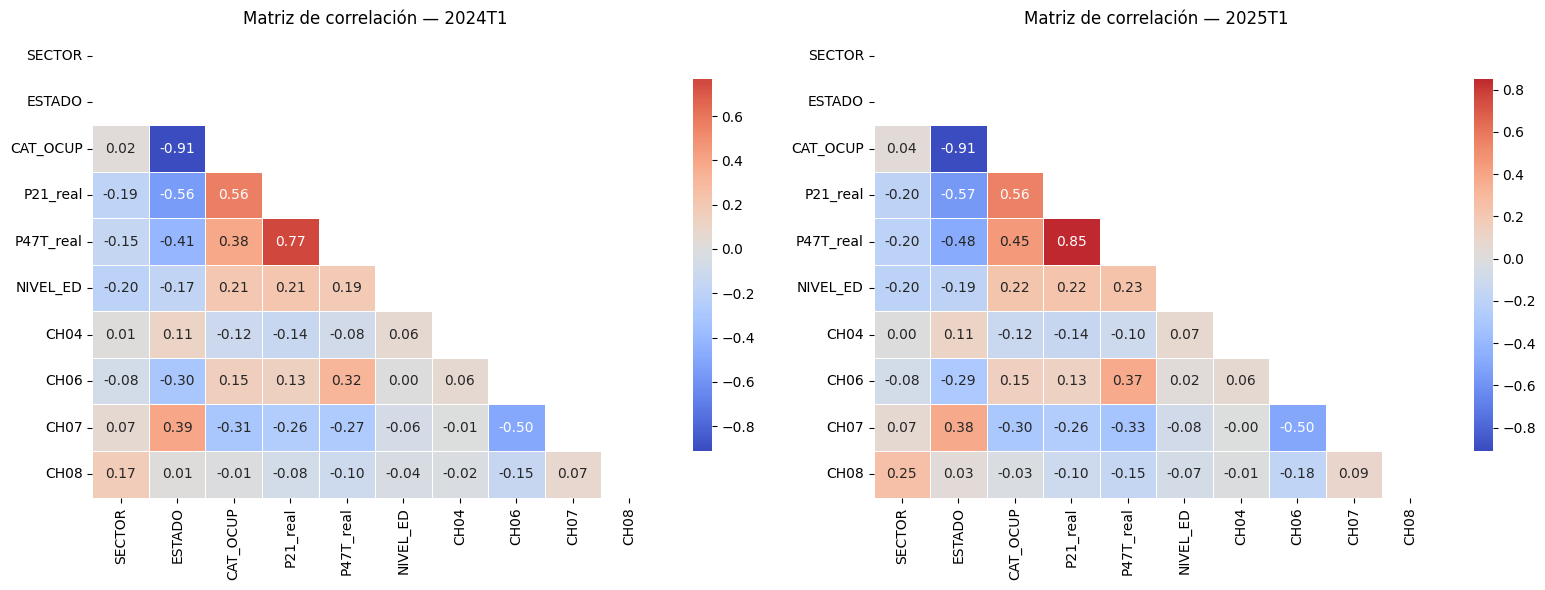

In [15]:
vars_corr = ['SECTOR', 'ESTADO', 'CAT_OCUP', 'P21_real', 'P47T_real',
             'NIVEL_ED', 'CH04', 'CH06', 'CH07', 'CH08']
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
for ax, (df, label) in zip(axes, [(df_24, '2024T1'), (df_25, '2025T1')]):
    corr = df[vars_corr].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))  
    sns.heatmap(
        corr, mask=mask,
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0,
        linewidths=0.4, ax=ax,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(f"Matriz de correlación — {label}", fontsize=12)
 
plt.tight_layout()
plt.savefig("correlacion.png", dpi=150)
plt.show()
 

Ahora siguiendo los **Principios de Schwabish (2014)**

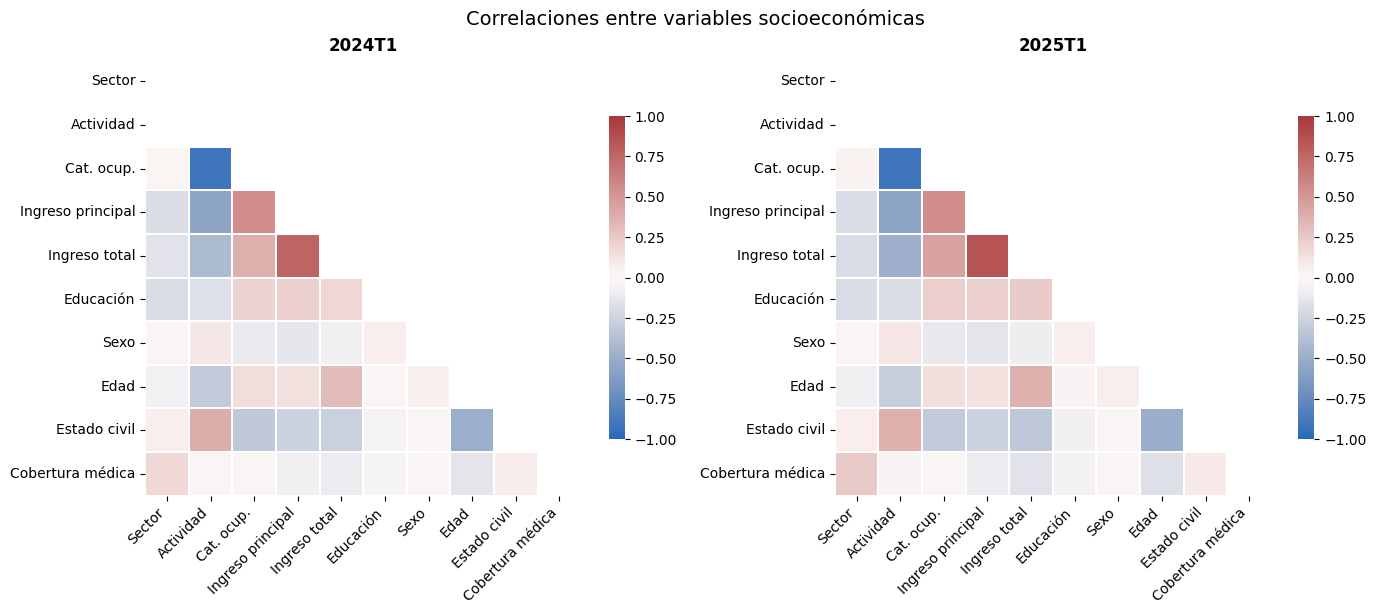

In [16]:
vars_corr = ['SECTOR', 'ESTADO', 'CAT_OCUP', 'P21_real', 'P47T_real',
             'NIVEL_ED', 'CH04', 'CH06', 'CH07', 'CH08']


labels = {
    'SECTOR': 'Sector',
    'ESTADO': 'Actividad',
    'CAT_OCUP': 'Cat. ocup.',
    'P21_real': 'Ingreso principal',
    'P47T_real': 'Ingreso total',
    'NIVEL_ED': 'Educación',
    'CH04': 'Sexo',
    'CH06': 'Edad',
    'CH07': 'Estado civil',
    'CH08': 'Cobertura médica'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df, year) in zip(axes, [(df_24, '2024T1'), (df_25, '2025T1')]):
    
    corr = df[vars_corr].corr()
    
    # máscara triángulo superior
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # heatmap limpio
    sns.heatmap(
        corr,
        mask=mask,
        cmap="vlag",          # más suave que coolwarm
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={"shrink": 0.7},
        ax=ax
    )
    
    # labels más legibles
    ax.set_xticklabels([labels[v] for v in vars_corr], rotation=45, ha='right')
    ax.set_yticklabels([labels[v] for v in vars_corr], rotation=0)
    
    ax.set_title(year, fontsize=12, weight='bold')

# título general claro
plt.suptitle("Correlaciones entre variables socioeconómicas", fontsize=14)

plt.tight_layout()
plt.savefig("correlacion_prolija.png", dpi=200)
plt.show()

**5. Estadística Descriptiva. Nos piden: n, media, desvío, mín, p1, p25, p50, p75, p99, máx**

In [17]:
# Comentar parte para guiar a Aroon

percentiles = [0.01, 0.25, 0.50, 0.75, 0.99]
 
def desc_stats(df, label):
    stats = df[vars_corr].describe(percentiles=percentiles)
    stats.loc['count'] = stats.loc['count'].astype(int)
    stats.index.name = label
    return stats
 
desc_24 = desc_stats(df_24, '2024T1')
desc_25 = desc_stats(df_25, '2025T1')
 
print("\n--- Estadística descriptiva 2024T1 ---")
print(desc_24.round(2).to_string())
print("\n--- Estadística descriptiva 2025T1 ---")
print(desc_25.round(2).to_string())


--- Estadística descriptiva 2024T1 ---
          SECTOR    ESTADO  CAT_OCUP     P21_real    P47T_real  NIVEL_ED      CH04      CH06      CH07      CH08
2024T1                                                                                                          
count   20325.00  46050.00  46050.00     42647.00     41107.00  46050.00  46050.00  45716.00  46050.00  46050.00
mean        1.66      2.20      1.26    184394.05    302334.60      3.75      1.52     36.57      3.52      2.15
std         1.60      1.14      1.40    379533.76    546242.64      1.75      0.50     22.06      1.66      2.37
min         1.00      0.00      0.00         0.00         0.00      1.00      1.00      1.00      1.00      1.00
1%          1.00      1.00      0.00         0.00         0.00      1.00      1.00      2.00      1.00      1.00
25%         1.00      1.00      0.00         0.00         0.00      3.00      1.00     18.00      2.00      1.00
50%         1.00      3.00      0.00         0.00    171

In [42]:
print((df_24['P21'] == 0).sum())
print((df_24['P21'] == 0).mean() * 100)

26134
56.751357220412594


## Parte 3: Conociendo la informalidad laboral

**7. Utilizando la definición de informalidad asignada al grupo (Grupo #2: Lower-tier informal wage emplyees) contestar unas preguntas**

**8. Visualización de Distribución de Ingresos** 



Me parece importante aclarar lo que hago con los valores extremos (outliers) ya que decidí no usar el ln de los ingresos. La idea es no tirar observaciones por mas que sean outliers y, además, le da mucho más input al gráfico. 

Las variables lim_p21 y lim_p47t lo que hacen es 'taponear' la distribución en su parte mas alta, esto es, el valor máx que pueden tomar mis observaciones en la cola derecha de la distribución será el valor del percentil 99. Toda observación con ingresos más altos al percentil 99 automáticamente se les imputará este valor. Esto es lo que hacemos con .clip(upper=lim_p21) y lo mismo para lim_p47t en el gráfico. 

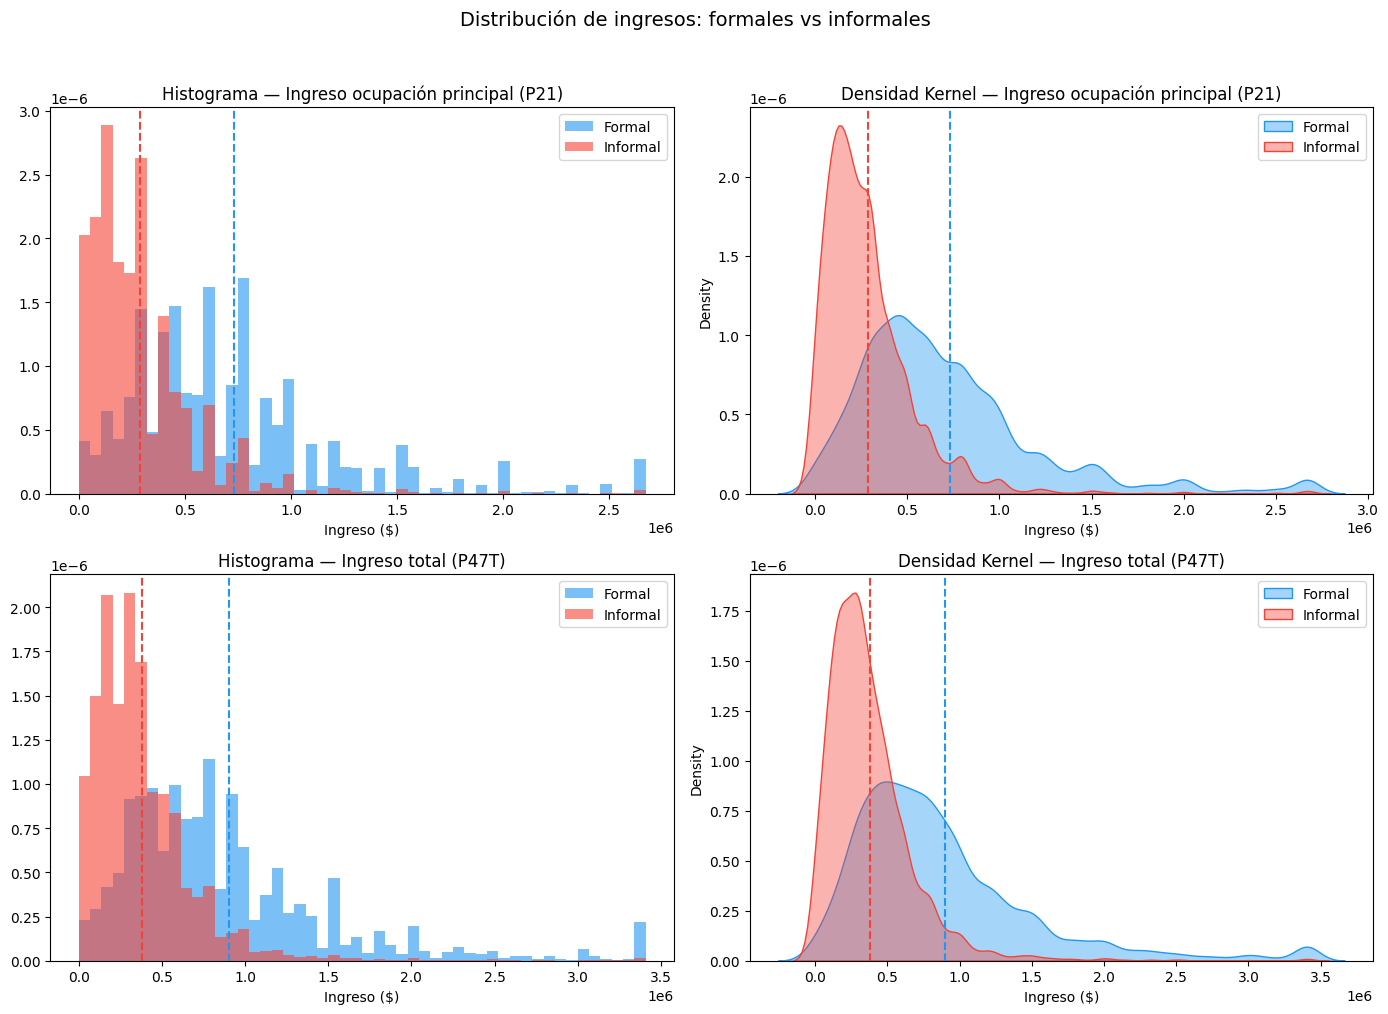

In [ ]:
# Usamos la submuestra de ocupados y separamos formal/informal. Esto es, entre los que respondieron y además están ocupados (ESTADO=1)
# separamos entre formales e informales según la dummy SECTOR (1 = formal, 0 = informal + hogares + Ns/Nr).
formales   = ocupados[ocupados['d_formal'] == 1]
informales = ocupados[ocupados['d_formal'] == 0]
 
# Paleta de colores
col_formal   = '#2196F3'   # azul
col_informal = '#F44336'   # rojo
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribución de ingresos: formales vs informales", fontsize=14, y=1.01)
 
# Límite superior para graficar (sacamos outliers extremos del plot)
lim_p21  = ocupados['P21_real'].quantile(0.99)
lim_p47t = ocupados['P47T_real'].quantile(0.99)
 
# Panel 1 - Histograma de P21
ax = axes[0, 0]

# 'Taponeo' de la distribución con .clip() 

ax.hist(formales['P21_real'].dropna().clip(upper=lim_p21),
        bins=50, alpha=0.6, color=col_formal, label='Formal', density=True)
ax.hist(informales['P21_real'].dropna().clip(upper=lim_p21),
        bins=50, alpha=0.6, color=col_informal, label='Informal', density=True)
ax.axvline(formales['P21_real'].dropna().mean(), color=col_formal, linestyle='--')
ax.axvline(informales['P21_real'].dropna().mean(), color=col_informal, linestyle='--')
ax.set_title("Histograma — Ingreso ocupación principal (P21)")
ax.set_xlabel("Ingreso ($)")
ax.legend()
 
# Panel 2 - KDE P21
ax = axes[0, 1]
sns.kdeplot(formales['P21_real'].dropna().clip(upper=lim_p21),
            ax=ax, color=col_formal, label='Formal', fill=True, alpha=0.4)
sns.kdeplot(informales['P21_real'].dropna().clip(upper=lim_p21),
            ax=ax, color=col_informal, label='Informal', fill=True, alpha=0.4)
ax.set_title("Densidad Kernel — Ingreso ocupación principal (P21)")
ax.set_xlabel("Ingreso ($)")
ax.axvline(formales['P21_real'].dropna().mean(), color=col_formal, linestyle='--')
ax.axvline(informales['P21_real'].dropna().mean(), color=col_informal, linestyle='--')
ax.legend()
 
# Panel 3 - Histograma P47T
ax = axes[1, 0]
ax.hist(formales['P47T_real'].dropna().clip(upper=lim_p47t),
        bins=50, alpha=0.6, color=col_formal, label='Formal', density=True)
ax.hist(informales['P47T_real'].dropna().clip(upper=lim_p47t),
        bins=50, alpha=0.6, color=col_informal, label='Informal', density=True)
ax.set_title("Histograma — Ingreso total (P47T)")
ax.set_xlabel("Ingreso ($)")
ax.axvline(formales['P47T_real'].dropna().mean(), color=col_formal, linestyle='--')
ax.axvline(informales['P47T_real'].dropna().mean(), color=col_informal, linestyle='--')
ax.legend()
 
# Panel 4 - KDE P47T 
ax = axes[1, 1]
sns.kdeplot(formales['P47T_real'].dropna().clip(upper=lim_p47t),
            ax=ax, color=col_formal, label='Formal', fill=True, alpha=0.4)
sns.kdeplot(informales['P47T_real'].dropna().clip(upper=lim_p47t),
            ax=ax, color=col_informal, label='Informal', fill=True, alpha=0.4)
ax.set_title("Densidad Kernel — Ingreso total (P47T)")
ax.set_xlabel("Ingreso ($)")
ax.axvline(formales['P47T_real'].dropna().mean(), color=col_formal, linestyle='--')
ax.axvline(informales['P47T_real'].dropna().mean(), color=col_informal, linestyle='--')
ax.legend()
 
plt.tight_layout()
plt.savefig("distribucion_ingresos.png", dpi=150)
plt.show()

Ahora **siguiendo los Principios de Schwabish (2014)**

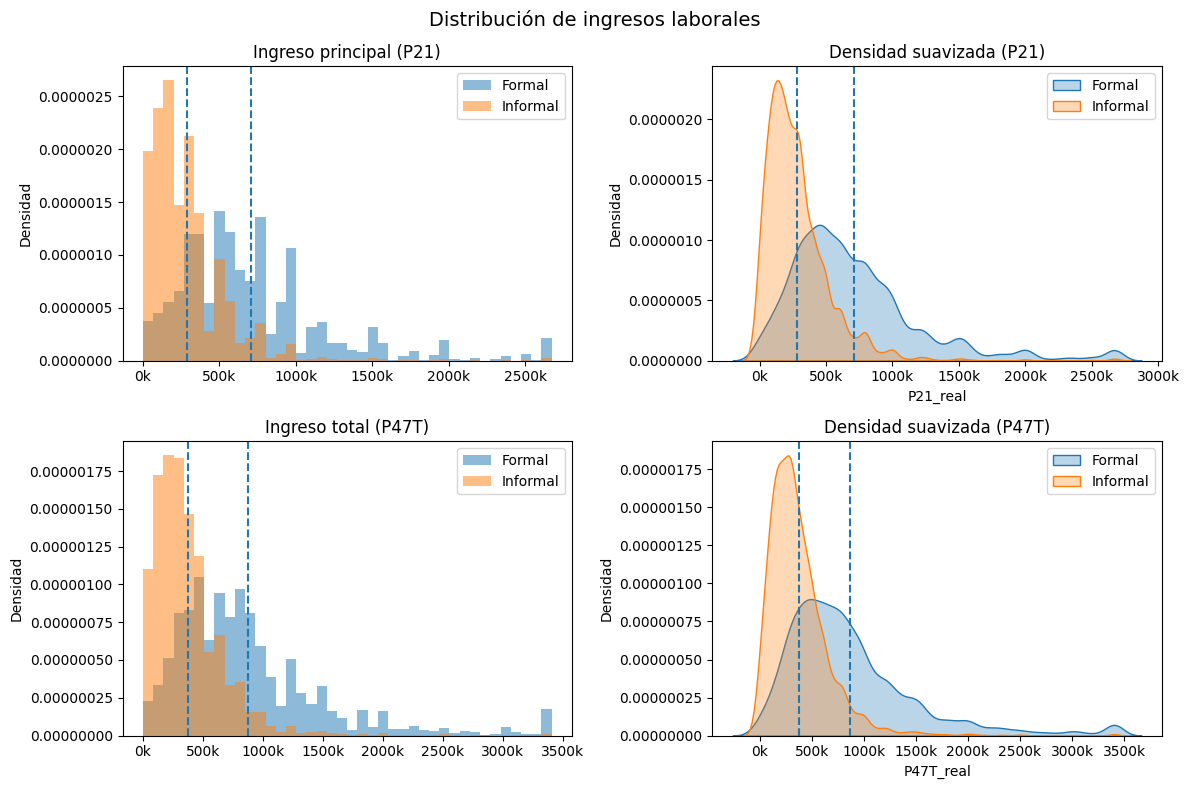

In [25]:
from matplotlib.ticker import FuncFormatter

# -------- FORMATTER PARA EJE X --------
def miles(x, pos):
    return f'{int(x/1000)}k'

# -------- SUBMUESTRAS --------
formales   = ocupados[ocupados['d_formal'] == 1]
informales = ocupados[ocupados['d_formal'] == 0]

# -------- LIMITES (recorte outliers) --------
lim_p21  = ocupados['P21_real'].quantile(0.99)
lim_p47t = ocupados['P47T_real'].quantile(0.99)

# -------- FIGURA --------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribución de ingresos laborales", fontsize=14)

# -------- PANEL 1: HIST P21 --------
ax = axes[0, 0]
ax.hist(formales['P21_real'].dropna().clip(upper=lim_p21),
        bins=40, alpha=0.5, label='Formal', density=True)
ax.hist(informales['P21_real'].dropna().clip(upper=lim_p21),
        bins=40, alpha=0.5, label='Informal', density=True)

ax.set_title("Ingreso principal (P21)")
ax.set_ylabel("Densidad")
ax.axvline(formales['P21_real'].dropna().clip(upper=lim_p21).mean(), linestyle='--')
ax.axvline(informales['P21_real'].dropna().clip(upper=lim_p21).mean(), linestyle='--')
ax.legend()

# -------- PANEL 2: KDE P21 --------
ax = axes[0, 1]
sns.kdeplot(formales['P21_real'].dropna().clip(upper=lim_p21),
            ax=ax, label='Formal', fill=True, alpha=0.3)
sns.kdeplot(informales['P21_real'].dropna().clip(upper=lim_p21),
            ax=ax, label='Informal', fill=True, alpha=0.3)

ax.set_title("Densidad suavizada (P21)")
ax.set_ylabel("Densidad")
ax.axvline(formales['P21_real'].dropna().clip(upper=lim_p21).mean(), linestyle='--')
ax.axvline(informales['P21_real'].dropna().clip(upper=lim_p21).mean(), linestyle='--')
ax.legend()

# -------- PANEL 3: HIST P47T --------
ax = axes[1, 0]
ax.hist(formales['P47T_real'].dropna().clip(upper=lim_p47t),
        bins=40, alpha=0.5, label='Formal', density=True)
ax.hist(informales['P47T_real'].dropna().clip(upper=lim_p47t),
        bins=40, alpha=0.5, label='Informal', density=True)

ax.set_title("Ingreso total (P47T)")
ax.set_ylabel("Densidad")
ax.axvline(formales['P47T_real'].dropna().clip(upper=lim_p47t).mean(), linestyle='--')
ax.axvline(informales['P47T_real'].dropna().clip(upper=lim_p47t).mean(), linestyle='--')
ax.legend()

# -------- PANEL 4: KDE P47T --------
ax = axes[1, 1]
sns.kdeplot(formales['P47T_real'].dropna().clip(upper=lim_p47t),
            ax=ax, label='Formal', fill=True, alpha=0.3)
sns.kdeplot(informales['P47T_real'].dropna().clip(upper=lim_p47t),
            ax=ax, label='Informal', fill=True, alpha=0.3)

ax.set_title("Densidad suavizada (P47T)")
ax.set_ylabel("Densidad")
ax.axvline(formales['P47T_real'].dropna().clip(upper=lim_p47t).mean(), linestyle='--')
ax.axvline(informales['P47T_real'].dropna().clip(upper=lim_p47t).mean(), linestyle='--')
ax.legend()

# -------- FORMATO EJES --------
for ax in axes.flatten():
    ax.xaxis.set_major_formatter(FuncFormatter(miles))  # 100k → "100k"
    ax.ticklabel_format(style='plain', axis='y')        # evita 1e-6

plt.tight_layout()
plt.show()

## Pregunta 7. Maurizio & Monsalvo (2021)

### **Definición - Lower-tier informal wage employees:  Trabajadores informales asalariados que trabajan en empresas con hasta cinco empleados.**

#### La pregunta fue respondida y graficada considerando dos formas distintas de definir la informalidad.

En los incisos anteriores, los informales fueron definidos de la siguiente manera:

$$
df\_año \;\rightarrow\; df\_resp \;\rightarrow\; ESTADO = 1 \;(\text{ocupados}) \;\rightarrow\; d\_formal = 1 \;(\text{SECTOR}=1)
$$

Es decir, la formalidad (o informalidad) se mide en función de si la **unidad económica** es formal.

---

En este inciso, se utilizan dos definiciones alternativas:

**Primera definición (filtrado sobre la unidad económica o clasificación del empleo):**

$$
df\_año \;\rightarrow\; df\_resp \;\rightarrow\; (sector\_formal \;\text{o}\; empleo\_formal)
$$

donde la restricción $pp04c \leq 5$ NO se incorpora.

---

**Segunda definición (Maurizio & Monsalvo, 2021):**

$$
df\_año \;\rightarrow\; df\_resp \;\rightarrow\; desc\_jub\_sino \;\rightarrow\; pp04c \leq 5
$$



In [38]:
# Tabla doble entrada de Formalidad e Informalidad para H, M y Total de cada año  
# Filtramos ocupados que respondieron, para cada año por separado
# Partimos de cada df original ---D respondieron (ESTADO != 0) ---D ocupados (ESTADO == 1)
ocu_24 = df_24[(df_24['ESTADO'] != 0) & (df_24['ESTADO'] == 1)].copy()
ocu_25 = df_25[(df_25['ESTADO'] != 0) & (df_25['ESTADO'] == 1)].copy()

# 'Dummy' para sexo (compartida por ambas definiciones)
# CH04 == 1 ENTONCES Varón | CH04 == 2 ENTONCES Mujer
for df in [ocu_24, ocu_25]:
    df['d_varon'] = (df['CH04'] == 1).astype(int)  # Si == 1 --D true para varón y te pone un 1, sino == 2 entonces false y te pone un 0 
    df['d_mujer'] = (df['CH04'] == 2).astype(int)

# DEFINICIÓN 1: formal si SECTOR==1 ó EMPLEO==1 — SIN restricción de PP04C
# El universo es todos los ocupados; informal = no cumple ninguna de las dos condiciones
for df in [ocu_24, ocu_25]:
    df['d_formal_def1']   = ((df['SECTOR'] == 1) | (df['EMPLEO'] == 1)).astype(int)
    df['d_informal_def1'] = 1 - df['d_formal_def1']

def tabla_formalidad(df, dummy_formal, año, definicion):
    grupos = {
        'Total':   df,
        'Mujeres': df[df['d_mujer'] == 1],
        'Hombres': df[df['d_varon'] == 1],
    }
    filas = []
    for grupo, subdf in grupos.items():
        total      = len(subdf)
        pct_form   = (subdf[dummy_formal] == 1).sum() / total * 100
        pct_inform = 100 - pct_form
        filas.append({
            'Grupo':        grupo,
            'Formal (%)':   round(pct_form, 1),
            'Informal (%)': round(pct_inform, 1),
            'N':            total
        })
    tabla = pd.DataFrame(filas).set_index('Grupo')
    tabla.columns.name = f'{año} — Def. {definicion}'
    return tabla

# Armamos la tabla para cada año con Definición 1 (universo completo, sin filtro de establecimiento PP04C)
tabla_24_def1 = tabla_formalidad(ocu_24, 'd_formal_def1', '2024T1', 1)
tabla_25_def1 = tabla_formalidad(ocu_25, 'd_formal_def1', '2025T1', 1)

print("=" * 70)
print("DEFINICIÓN 1: SECTOR==1 ó EMPLEO==1  |  sin restricción PP04C")
print("=" * 70)
print("\n--- 2024T1 ---")
print(tabla_24_def1.to_string())
print("\n--- 2025T1 ---")
print(tabla_25_def1.to_string())

# DEFINICIÓN 2 (Maurizio & Monsalvo): informal si PP04C<=5 AND PP07H!=1
# La condición PP04C<=5 es parte de la definición de informalidad, NO un filtro del universo
# Así el denominador (N total) es el mismo que Def 1 ---D los % son comparables
ocu_24['d_informal_def2'] = ((ocu_24['PP04C'] <= 5) & (ocu_24['PP07H'] != 1)).astype(int)
ocu_24['d_formal_def2']   = 1 - ocu_24['d_informal_def2']

ocu_25['d_informal_def2'] = ((ocu_25['PP04C'] <= 5) & (ocu_25['PP07H'] != 1)).astype(int)
ocu_25['d_formal_def2']   = 1 - ocu_25['d_informal_def2']

tabla_24_def2 = tabla_formalidad(ocu_24, 'd_formal_def2', '2024T1', 2)
tabla_25_def2 = tabla_formalidad(ocu_25, 'd_formal_def2', '2025T1', 2)

print("\n" + "=" * 70)
print("DEFINICIÓN 2 (Maurizio & Monsalvo): PP04C<=5 AND PP07H!=1")
print("=" * 70)
print("\n--- 2024T1 ---")
print(tabla_24_def2.to_string())
print("\n--- 2025T1 ---")
print(tabla_25_def2.to_string())

# Tablas agrupadas
# Así podemos ver si hay algo raro en la comparación entre años o entre definiciones
consolidada = pd.concat(
    [tabla_24_def1, tabla_25_def1, tabla_24_def2, tabla_25_def2],
    axis=1,
    keys=['2024T1 Def1', '2025T1 Def1', '2024T1 Def2', '2025T1 Def2']
)
print("\n" + "=" * 70)
print("TABLA CONSOLIDADA")
print("=" * 70)
print(consolidada.to_string())

DEFINICIÓN 1: SECTOR==1 ó EMPLEO==1  |  sin restricción PP04C

--- 2024T1 ---
2024T1 — Def. 1  Formal (%)  Informal (%)      N
Grupo                                           
Total                  69.5          30.5  20325
Mujeres                69.3          30.7   9112
Hombres                69.8          30.2  11213

--- 2025T1 ---
2025T1 — Def. 1  Formal (%)  Informal (%)      N
Grupo                                           
Total                  68.3          31.7  20076
Mujeres                68.0          32.0   8967
Hombres                68.5          31.5  11109

DEFINICIÓN 2 (Maurizio & Monsalvo): PP04C<=5 AND PP07H!=1

--- 2024T1 ---
2024T1 — Def. 2  Formal (%)  Informal (%)      N
Grupo                                           
Total                  61.0          39.0  20325
Mujeres                59.6          40.4   9112
Hombres                62.2          37.8  11213

--- 2025T1 ---
2025T1 — Def. 2  Formal (%)  Informal (%)      N
Grupo                          

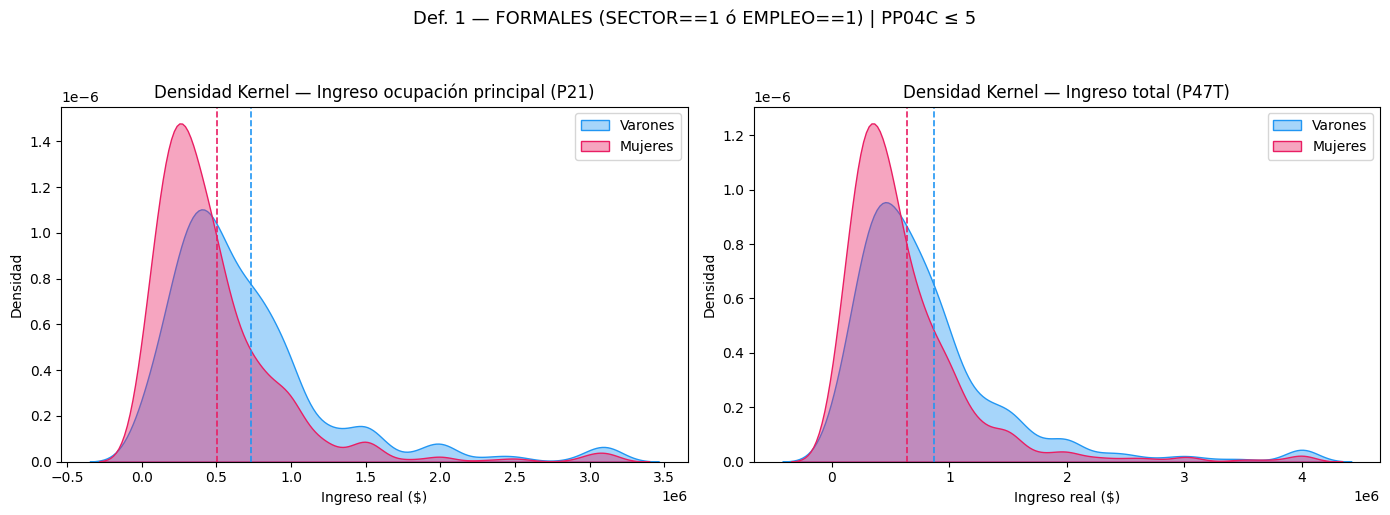

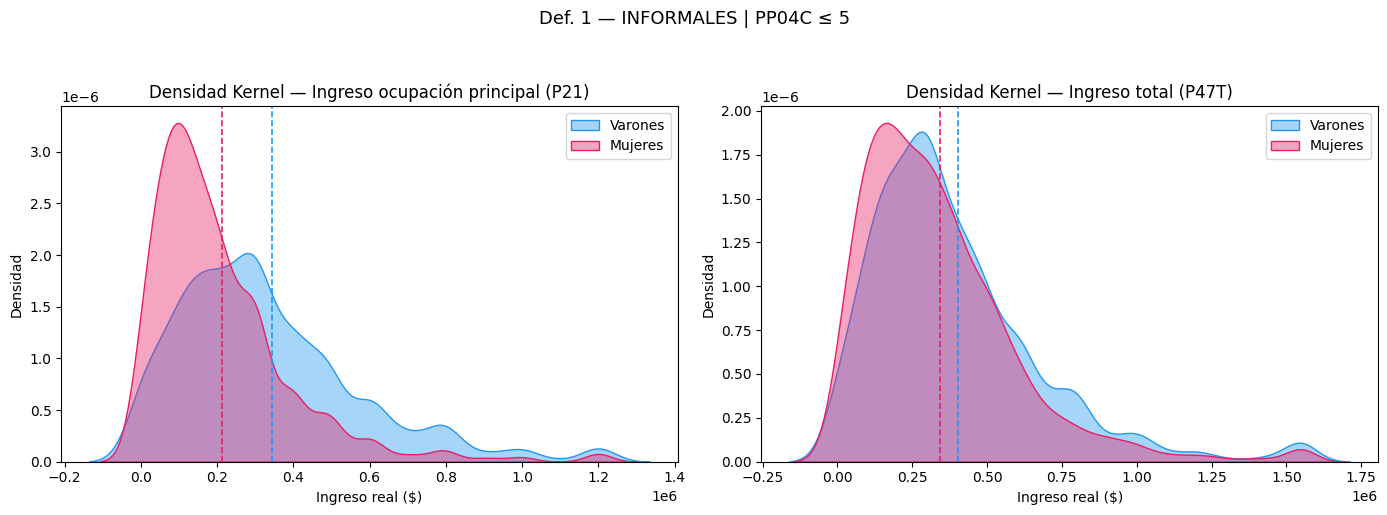

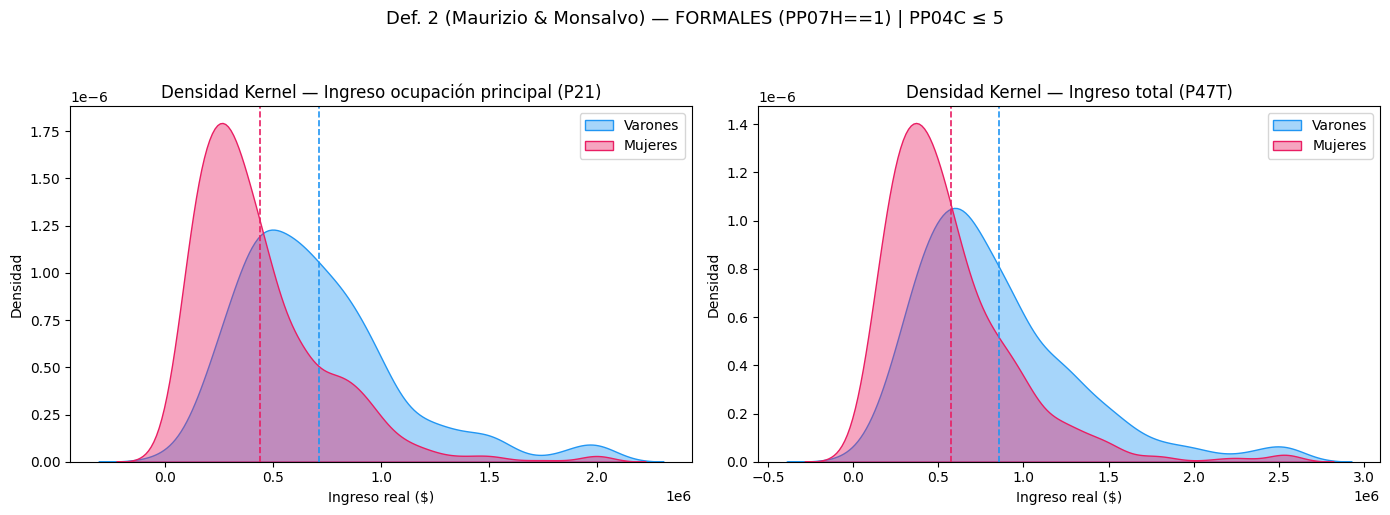

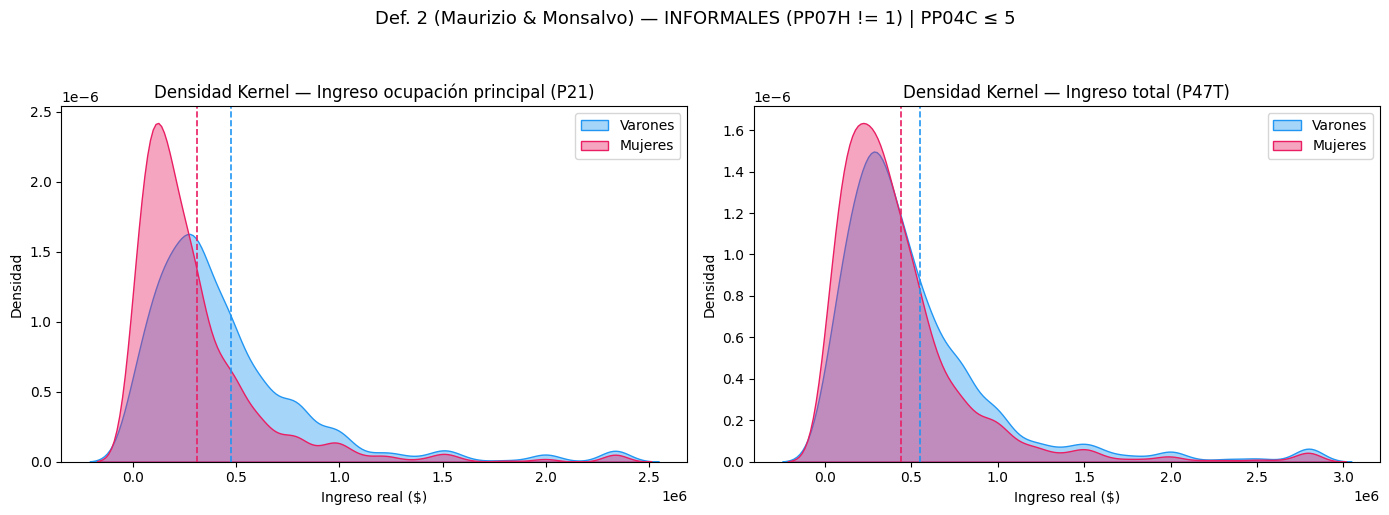

In [33]:
# KDE por sexo: Formales e Informales - 2 definiciones × 2 grupos

# Colores por sexo
col_varon  = '#2196F3'   # azul
col_mujer  = '#E91E63'   # rosa/fucsia

# ─────────────────────────────────────────────────────────────────────────────
# ## Helper: construye un gráfico KDE de 2 paneles (P21 y P47T) por sexo
# ─────────────────────────────────────────────────────────────────────────────

def kde_por_sexo(df_grupo, titulo, filename):
    """
    df_grupo : submuestra ya filtrada (ej: formales según Def1)
    Grafico KDE de P21_real y P47T_real separando hombres y mujeres.
    """
    varones = df_grupo[df_grupo['d_varon'] == 1]
    mujeres = df_grupo[df_grupo['d_mujer'] == 1]

    # Límites para 'taponeo' de outliers (percentil 99 sobre el grupo)
    lim_p21  = df_grupo['P21_real'].quantile(0.99)
    lim_p47t = df_grupo['P47T_real'].quantile(0.99)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(titulo, fontsize=13, y=1.02)

    # --- Panel izquierdo: KDE P21_real ---
    ax = axes[0]
    sns.kdeplot(varones['P21_real'].dropna().clip(upper=lim_p21),
                ax=ax, color=col_varon, label='Varones', fill=True, alpha=0.4)
    sns.kdeplot(mujeres['P21_real'].dropna().clip(upper=lim_p21),
                ax=ax, color=col_mujer, label='Mujeres', fill=True, alpha=0.4)
    ax.axvline(varones['P21_real'].dropna().mean(), color=col_varon, linestyle='--', linewidth=1.2)
    ax.axvline(mujeres['P21_real'].dropna().mean(), color=col_mujer,  linestyle='--', linewidth=1.2)
    ax.set_title("Densidad Kernel — Ingreso ocupación principal (P21)")
    ax.set_xlabel("Ingreso real ($)")
    ax.set_ylabel("Densidad")
    ax.legend()

    # --- Panel derecho: KDE P47T_real ---
    ax = axes[1]
    sns.kdeplot(varones['P47T_real'].dropna().clip(upper=lim_p47t),
                ax=ax, color=col_varon, label='Varones', fill=True, alpha=0.4)
    sns.kdeplot(mujeres['P47T_real'].dropna().clip(upper=lim_p47t),
                ax=ax, color=col_mujer, label='Mujeres', fill=True, alpha=0.4)
    ax.axvline(varones['P47T_real'].dropna().mean(), color=col_varon, linestyle='--', linewidth=1.2)
    ax.axvline(mujeres['P47T_real'].dropna().mean(), color=col_mujer,  linestyle='--', linewidth=1.2)
    ax.set_title("Densidad Kernel — Ingreso total (P47T)")
    ax.set_xlabel("Ingreso real ($)")
    ax.set_ylabel("Densidad")
    ax.legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Construimos las 4 submuestras (ya lo tengo del bloque anterior)
# Apilamos 2024 y 2025 para tener más potencia
# ─────────────────────────────────────────────────────────────────────────────

# Concatenamos los df filtrados de ambos años para cada definición
def1_total = pd.concat([ocu_24_def1, ocu_25_def1], ignore_index=True)
def2_total = pd.concat([ocu_24_def2, ocu_25_def2], ignore_index=True)

# Separamos formales e informales para cada definición
formales_def1   = def1_total[def1_total['d_formal_def1'] == 1]
informales_def1 = def1_total[def1_total['d_formal_def1'] == 0]

formales_def2   = def2_total[def2_total['d_formal_def2'] == 1]
informales_def2 = def2_total[def2_total['d_formal_def2'] == 0]


# ─────────────────────────────────────────────────────────────────────────────
# ## Los 4 gráficos
# ─────────────────────────────────────────────────────────────────────────────

kde_por_sexo(
    formales_def1,
    "Def. 1 — FORMALES (SECTOR==1 ó EMPLEO==1) | PP04C ≤ 5",
    "kde_def1_formales.png"
)

kde_por_sexo(
    informales_def1,
    "Def. 1 — INFORMALES | PP04C ≤ 5",
    "kde_def1_informales.png"
)

kde_por_sexo(
    formales_def2,
    "Def. 2 (Maurizio & Monsalvo) — FORMALES (PP07H==1) | PP04C ≤ 5",
    "kde_def2_formales.png"
)

kde_por_sexo(
    informales_def2,
    "Def. 2 (Maurizio & Monsalvo) — INFORMALES (PP07H != 1) | PP04C ≤ 5",
    "kde_def2_informales.png"
)

**FIN**